In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import pacmap
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import scipy.sparse
import sympy
import sklearn.datasets
import sklearn.feature_extraction.text
import umap
import umap.plot
import matplotlib.pyplot as plt
from numpy.random import rand
from numpy import genfromtxt
%matplotlib inline

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/usr/local/lib/python3.10/dist-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/pyth

In [2]:
repo_folder = "/are/logs/are/meim_env_pressure_alife/10k_runs/"
experiments = {
    "directory" :  ['meimflat', 'meimhill', 'meimholes', 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'hollyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Hollyrood'],
}

In [3]:
def load_sparse_morph(name, folders):
  _robots_loaded = 0
  _morph_sparse = []
  _morph_fitness = np.empty((0))
  _morph_labels = []
  for folder in folders:
      print(folder)
      _morph_dense = genfromtxt(folder + '/morph_descriptor.csv', delimiter=',')
      _morph_fit = genfromtxt(folder + '/fitness.csv', delimiter=',')[:,3]
      assert _morph_dense.shape[0] == _morph_fit.shape[0]
      print(_morph_dense.shape)
      _morph_fit = _morph_fit / np.max(_morph_fit)
      _morph_fitness = np.append(_morph_fitness, _morph_fit, axis=0)
      _robots_loaded += _morph_dense.shape[0]
      if _morph_sparse == []:
          _morph_sparse = scipy.sparse.lil_matrix(_morph_dense[:, 2:])
      else:
          temp_sparse = scipy.sparse.lil_matrix(_morph_dense[:, 2:])
          print("temp_sparse", temp_sparse.shape)
          _morph_sparse = scipy.sparse.vstack([_morph_sparse, temp_sparse])
      print("sparse", _morph_sparse.shape)
  _morph_labels = np.array([name] * _robots_loaded)
  return _morph_sparse, _morph_fitness, _morph_labels, _robots_loaded

In [4]:
morph_labels = []
morph_sparse = []
morph_fitness = np.empty((0))
robots_loaded = 0
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    _ms, _mf, _ml, _rl = load_sparse_morph(experiments['name'][idx], folders)
    robots_loaded += _rl
    if morph_sparse == []:
      morph_sparse = _ms
    else:
      morph_sparse = scipy.sparse.vstack([morph_sparse, _ms])
    print("morph_sparse", morph_sparse.shape)
    morph_fitness = np.append(morph_fitness, _mf, axis=0)
    morph_labels = np.append(morph_labels, _ml, axis=0)
print(morph_fitness.shape)
print(len(morph_labels))
print(morph_sparse.shape)
print(robots_loaded) 

meimflat
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_8/meim_11_3_19-16-10-816-2370462392
(10046, 1333)
sparse (10046, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_9/meim_12_3_1-34-14-4030-2971763921
(10004, 1333)
temp_sparse (10004, 1331)
sparse (20050, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_7/meim_11_3_17-59-59-9003-1516430376
(10024, 1333)
temp_sparse (10024, 1331)
sparse (30074, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_10/meim_12_3_1-54-59-9138-4171306948
(10000, 1333)
temp_sparse (10000, 1331)
sparse (40074, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_4/meim_11_3_17-59-57-7377-2053156979
(10036, 1333)
temp_sparse (10036, 1331)
sparse (50110, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/55742_1/meim_11_3_17-59-57-7269-4229270083
(10000, 1333)
temp_sparse (10000, 1331)
sparse (60110, 1331)
/are/logs/are/meim_env_pressure_alife/10k_runs/meimflat/557

In [101]:
print(morph_fitness.shape)
print(morph_labels.shape)
print(morph_sparse.shape)
print(robots_loaded) 
np.min(morph_fitness)

(592838,)
(592838,)
(592838, 1331)
592838


0.0

In [5]:
%%time
pacmap_model = pacmap.PaCMAP(n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0)
morph_sparse_pacmap = pacmap_model.fit_transform(morph_sparse.toarray())

CPU times: user 18min 10s, sys: 1min 27s, total: 19min 37s
Wall time: 8min 44s


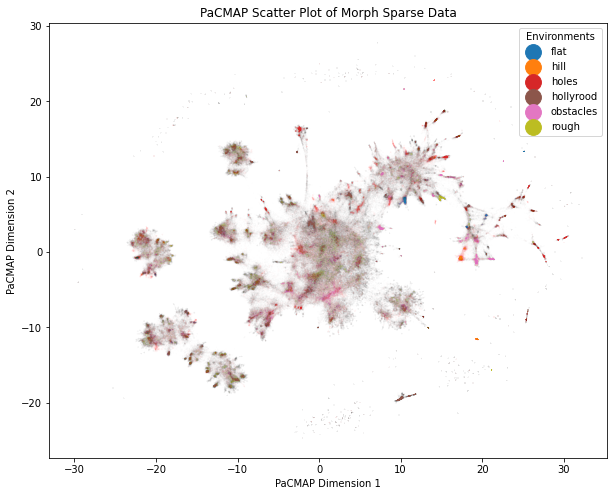

In [13]:
plt.figure(figsize=(10, 8))
#plt.scatter(morph_sparse_pacmap[:, 0], morph_sparse_pacmap[:, 1], s=1, alpha=0.01)
plt.title("PaCMAP Scatter Plot of Morph Sparse Data")
plt.xlabel("PaCMAP Dimension 1")
plt.ylabel("PaCMAP Dimension 2")
# Map unique environment labels to colors
unique_labels = np.unique(morph_labels)
colors = {label: plt.cm.tab10(i / len(unique_labels)) for i, label in enumerate(unique_labels)}

# Apply colors to the scatter plot
point_colors = [colors[label] for label in morph_labels]
plt.scatter(morph_sparse_pacmap[:, 0], morph_sparse_pacmap[:, 1], c=point_colors, s=1, alpha=0.005)

# Add legend
for label, color in colors.items():
  plt.scatter([], [], c=[color], label=label, s=10)
plt.legend(title="Environments", loc='upper right', markerscale=5)
plt.show()

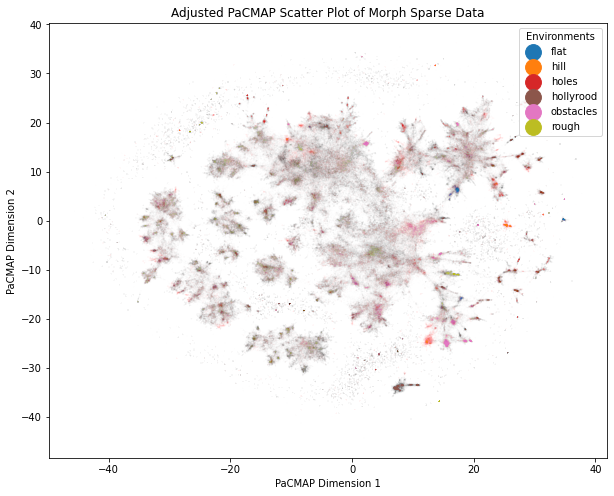

In [17]:
# Fit a new PaCMAP model with adjusted parameters
#pacmap_model_adjusted = pacmap.PaCMAP(n_neighbors=5, MN_ratio=0.2, FP_ratio=5.0)
#morph_sparse_pacmap_adjusted = pacmap_model_adjusted.fit_transform(morph_sparse.toarray())

# Plot the adjusted PaCMAP results
plt.figure(figsize=(10, 8))
plt.title("Adjusted PaCMAP Scatter Plot of Morph Sparse Data")
plt.xlabel("PaCMAP Dimension 1")
plt.ylabel("PaCMAP Dimension 2")

# Map unique environment labels to colors
point_colors_adjusted = [colors[label] for label in morph_labels]
plt.scatter(morph_sparse_pacmap_adjusted[:, 0], morph_sparse_pacmap_adjusted[:, 1], c=point_colors_adjusted, s=1, alpha=0.005)

# Add legend
for label, color in colors.items():
  plt.scatter([], [], c=[color], label=label, s=10)
plt.legend(title="Environments", loc='upper right', markerscale=5)
plt.show()